In [1]:
import torch
import numpy as np

from renderer import RelativeSpec, FigureSpec, BoxPatch, ImagePatch, TextPatch, CubePatch, ArrowConnector, render_objects
from dinosaw.helpers import add_custom_font, get_models, ModelTypes, get_features
from dinosaw.utils import do_2D_pca

from os import listdir
from PIL import Image
from PIL.ImageColor import getcolor

from skimage.transform import resize
from skimage.color import label2rgb

from interactive_seg_backend import TrainingConfig, FeatureConfig, featurise, concat_feats, train_and_apply
from interactive_seg_backend.file_handling import load_labels

# from typing import TypeAlias, Literal

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

SEED = 100001
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda:0'
half = False

flash attention installed
N CPUS: 110


In [2]:
enabled_models: tuple[ModelTypes, ...] = ('dv2', 'alibi_dv2_coco')
models = get_models(enabled_models, "../../trained_models", DEVICE, half)

f_cfg = FeatureConfig()
tr_cfg = TrainingConfig(feature_config=f_cfg, CRF=False, classifier='xgb', CRF_params={"label_confidence": 0.6,
    "sxy_g": [3, 3],
    "sxy_b": [80, 80],
    "s_rgb": [13, 13, 13],
    "compat_g": 10,
    "compat_b": 10,
    "n_infer": 10}, classifier_params={"class_weight": "balanced", "max_depth": 8}) 

In [3]:
sofc_img = Image.open("data/summary/default_image.jpg").convert('RGB')
w, h = sofc_img.size

# sofc_feats = get_features(models['dv2'], sofc_img, device=DEVICE)
# sofc_feats_red = do_2D_pca(sofc_feats, 9, post_norm='minmax')
# sofc_feats_red = sofc_feats.transpose((1, 2, 0))

In [4]:
sofc_feats: dict[ModelTypes, np.ndarray] = {}
for model in enabled_models:
    feats = get_features(models[model], sofc_img, device=DEVICE)
    feats_red = do_2D_pca(feats, 9, post_norm='minmax')
    feats_red_hr = resize(feats_red, (h, w), order=1)
    sofc_feats[model] = feats_red_hr

In [5]:
preds: dict[ModelTypes, np.ndarray] = {}

for model in enabled_models:
    feats = sofc_feats[model]
    labels = load_labels("data/summary/labels.tiff")[0]
    
    pred, _, _ = train_and_apply(feats, labels, tr_cfg, image=np.array(sofc_img))
    preds[model] = pred

2026-02-27 11:22:34 | I | core.py                    :122 | Training XGBClassifier: (10692, 9) -> ((10692,)) 
2026-02-27 11:22:34 | I | core.py                    :137 | Applying XGBClassifier to (896, 1024, 9) features
2026-02-27 11:22:34 | I | core.py                    :122 | Training XGBClassifier: (10692, 9) -> ((10692,)) 
2026-02-27 11:22:34 | I | core.py                    :137 | Applying XGBClassifier to (896, 1024, 9) features


/home/ronan/miniconda3/envs/dv2/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [11:22:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "class_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [6]:
COLOURS = [
    "#648FFF",
    "#785EF0",
    "#DC267F",
    "#FE6100",
    "#FFB000"
]
COLORS = [[v / 255.0 for v in getcolor(c, "RGB")] for c in COLOURS]

def hide_axis(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

def apply_labels_as_overlay(labels: np.ndarray, img: Image.Image, colors: list, alpha: float=1.0) -> Image.Image:
    labels_unsqueezed = np.expand_dims(labels, -1)

    overlay = label2rgb(labels, colors=colors[1:], kind='overlay', bg_label=0, image_alpha=1, alpha=alpha)
    out = np.where(labels_unsqueezed, overlay * 255, np.array(img)).astype(np.uint8)
    img_with_labels = Image.fromarray(out)
    return img_with_labels

FS = 22

In [7]:
def render_to_figure(ax) -> None:
    W, H = 6, 3
    # fig = plt.figure(figsize=(W, H))
    # ax = plt.gca()

    R_BOX_WIDTH = 0.25
    R_BOX_HEIGHT = 0.15
    R_BOX_SEP = 0.45

    ALIBI_Y = 0.3
    ALIBI_X = 0.45
    DINO_Y = ALIBI_Y + R_BOX_SEP

    DINO_COLOR = "#91bbff"
    ALIBI_COLOR = "#EDB458"
    alibi_box = BoxPatch(
        FigureSpec(
            ALIBI_X,
            ALIBI_Y,
            R_BOX_WIDTH,
            R_BOX_HEIGHT,
        ),
        fancy=True,
        facecolor=ALIBI_COLOR,
    )
    alibi_text = TextPatch(
        RelativeSpec(alibi_box, (0.075, 0.025), 0.1, 0.1),
        "ALiBi-Dv2",
        fontsize=FS - 2,
        ha="center",
        va="center",
        bold=True,
    )
    remove_pe_text = TextPatch(
        RelativeSpec(alibi_text, (0, 0.15), 0.1, 0.1),
        "(zero learned PE)",
        fontsize=FS - 4,
        ha="center",
        va="center",
        color="#555555",
    )

    dino_box = BoxPatch(
        FigureSpec(
            ALIBI_X,
            DINO_Y,
            R_BOX_WIDTH,
            R_BOX_HEIGHT,
        ),
        fancy=True,
        facecolor=DINO_COLOR,
    )
    dino_text = TextPatch(
        RelativeSpec(dino_box, (0.075, 0.025), 0.1, 0.1), "DINOv2", fontsize=FS - 2, ha="center", va="center"
    )
    frozen_text = TextPatch(
        RelativeSpec(dino_text, (0, 0.15), 0.1, 0.1), "(frozen)", fontsize=FS - 4, ha="center", va="center", color="#555555"
    )

    IMG_L = 0.15
    img = np.array(Image.open("data/summary/gv/patches.png"))

    IMG_REL_LOC = (ALIBI_X-0.4, DINO_Y - IMG_L / 2  )
    patch_img = ImagePatch(FigureSpec(*IMG_REL_LOC, IMG_L, (W / H) * IMG_L), img)

    MAT_L = IMG_L
    DIST_MAT_REL_LOC = (IMG_REL_LOC[0], ALIBI_Y - 0.3)
    dist_mat = np.array(Image.open("data/summary/gv/distance_matrix.png"))
    dist_mat_img = ImagePatch(FigureSpec(*DIST_MAT_REL_LOC, MAT_L, (W / H) * MAT_L), dist_mat)

    CUBE_L = 0.1
    CUBE_OFF_X = 0.38
    dino_cube = CubePatch(FigureSpec(ALIBI_X + CUBE_OFF_X, dino_box.mid_y - CUBE_L, CUBE_L, (W / H) * CUBE_L), depth_ratio=0.2, color=DINO_COLOR)
    alibi_cube = CubePatch(
        FigureSpec(dino_cube.x0, alibi_box.mid_y - CUBE_L, CUBE_L, (W / H) * CUBE_L), depth_ratio=0.2, color=ALIBI_COLOR
    )

    LW = 2
    # l1 = ArrowConnector(patch_img, dino_box, ("right", 0.6), ("left", 0.5), shrinkB=0.02, lw=LW)
    l1 = ArrowConnector(dino_box, None, ("left", 0.5), arrowstyle='<-', dy=0, dx=-0.3, shrinkA=0.02, lw=LW)
    l2 = ArrowConnector(
        l1,
        RelativeSpec(alibi_box, (-0.1, R_BOX_HEIGHT / 2), 0, 0),
        ("bottom", 0.67),
        arrowstyle="-",
        shrinkA=-0.005,
        shrinkB=-0.005,
        lw=LW
    )
    l3 = ArrowConnector(l2, alibi_box, ("right", 0.0), ("left", 0.5), arrowstyle="->", shrinkA=-0.005, shrinkB=0.02, lw=LW)
    l4 = ArrowConnector(dino_box, dino_cube, ("right", 0.5), ("left", 0.5), shrinkB=0.01, lw=LW)
    l5 = ArrowConnector(alibi_box, alibi_cube, ("right", 0.5), ("left", 0.5), shrinkB=0.01, lw=LW)
    l6 = ArrowConnector(
        dino_cube, alibi_cube, ("bottom", 0.5), ("top", 0.5), shrinkA=0.02, shrinkB=0.05, arrowstyle="<->", lw=LW
    )
    l7 = ArrowConnector(
        dist_mat_img,
        None,
        ("right", 0.5),
        None,
        dx=0.480,
        dy=0,
        arrowstyle="-",
        shrinkA=-0.005,
        lw=LW
    )
    

    loss_text = TextPatch(
        RelativeSpec(l6, (0.05, 0.14), 0.0, 0.0), r"$\mathcal{L}$", fontsize=FS + 4, ha="center", va="center", bold=True
    )
    rel_dist_text = TextPatch(
        RelativeSpec(l7, (0.22, -0.05), 0.0, 0.0), "Relative distance matrix", fontsize=FS - 4, ha="center", va="center"
    )

    # --- New: Internal and external connectors ---
    # Set N for number of internal/external lines
    N = 5
    internal_lines = []
    external_lines = []
    for i in range(N):
        frac = (i + 0.5) / N  # center them in the box
        external = ArrowConnector(
            alibi_box, None, ("bottom", frac), None, dx=0, dy=-0.15, arrowstyle="<-", linestyle="solid", lw=LW, shrinkA=0.02, shrinkB=-0.005
        )
        external_lines.append(external)
    
    

    attn_text = TextPatch(
        RelativeSpec(external, (0.1, 0.04), 0.0, 0.0), "Attention\nlayers", fontsize=FS - 4, ha="center", va="center"
    )

    # ---
    lines = [l1, l2, l3, l4, l5, l6, l7] + external_lines
    boxes = [alibi_box, dino_box] + internal_lines
    cubes = [dino_cube, alibi_cube]
    images = [patch_img, dist_mat_img]
    text = [alibi_text, frozen_text, dino_text, remove_pe_text, loss_text, rel_dist_text, attn_text]

    objs = lines + boxes + cubes + images + text

    render_objects(ax, objs, grid_shape=(1, 2))


<PIL.Image.Image image mode=RGB size=1024x896 at 0x7F7AD0265EE0> [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


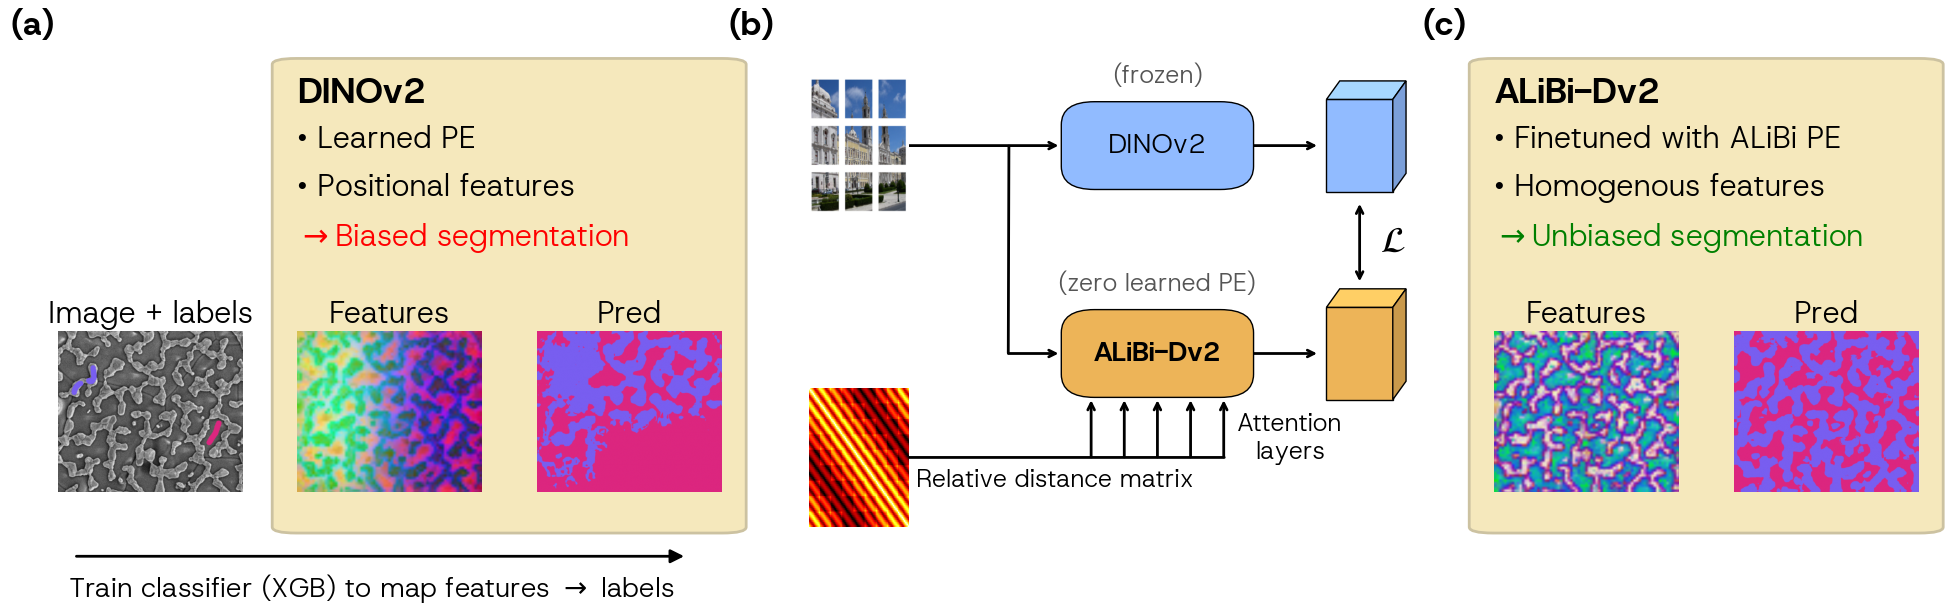

In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import numpy as np
from matplotlib.transforms import Bbox


add_custom_font('resources/fonts', 'Grotesk')

# ----------------------------
# Configuration
# ----------------------------

use_spacers = False           # Add spacer columns/rows
add_panel_labels = True      # Add (a), (b), (c) labels

# Width ratios for the 7 logical columns
base_widths = [1, 1, 1, 1, 1, 1, 1, 1]  # 3 small | 2 large | 2 small

W, H = 3, 3

# Insert spacer columns (between logical blocks)
if use_spacers:
    spacer_w = 0.2
    # Insert spacer after col 2 and after col 4
    width_ratios = [
        base_widths[0],
        base_widths[1],
        base_widths[2],
        spacer_w,
        base_widths[3],
        base_widths[4],
        spacer_w,
        base_widths[5],
        base_widths[6],
    ]
else:
    width_ratios = base_widths


height_ratios = [1, 1]

# ----------------------------
# Example image data
# Replace with actual images
# ----------------------------

def random_image(seed):
    rng = np.random.default_rng(seed)
    return rng.random((200, 200, 3))

small_images = [random_image(i) for i in range(5)]
large_image = np.random.default_rng(0).random((400, 400, 3))

# ----------------------------
# Figure and GridSpec
# ----------------------------

N_ROWS = len(height_ratios)
N_COLS = len(width_ratios)

fig_w = sum([W * r for r in width_ratios])

fig = plt.figure(figsize=(W * N_COLS, H * N_ROWS))
gs = gridspec.GridSpec(
    nrows=N_ROWS,
    ncols=N_COLS,
    width_ratios=width_ratios,
    height_ratios=height_ratios,
    figure=fig,
    wspace=0.3,
    hspace=0.0
)

# Helper to map logical column index -> actual index with spacers
def col_idx(logical_idx):
    if not use_spacers:
        return logical_idx
    # spacer after col 2 and col 4
    if logical_idx <= 2:
        return logical_idx
    elif logical_idx <= 4:
        return logical_idx + 1
    else:
        return logical_idx + 2

# Logical row indices

row_top = 0
row_bottom = 1

# ----------------------------
# Small images (bottom row)
# ----------------------------

axes_small = []

# LHS small images (cols 0,1,2)
for i in range(3):
    ax = fig.add_subplot(gs[row_bottom, col_idx(i)])
    # ax.imshow(small_images[i])
    ax.set_axis_off()
    axes_small.append(ax)

# RHS small images (cols 5,6)
for i, logical_col in enumerate([6, 7]):
    ax = fig.add_subplot(gs[row_bottom, col_idx(logical_col)])
    # ax.imshow(small_images[3 + i])
    ax.set_axis_off()
    axes_small.append(ax)

print(sofc_img, labels)
sofc_with_labels = apply_labels_as_overlay(labels, sofc_img, COLORS, alpha=1)
sofc_img_ax = axes_small[0]
sofc_img_ax.imshow(sofc_with_labels)
sofc_img_ax.set_title("Image + labels", fontsize=FS)

dv2_feat_ax = axes_small[1]
dv2_feat_ax.imshow(sofc_feats['dv2'][:, :, :3])
dv2_feat_ax.set_title("Features", fontsize=FS)

dv2_pred_ax = axes_small[2]
dv2_pred = label2rgb(preds['dv2'] + 1, colors=COLORS[1:], kind='overlay', bg_label=0, image_alpha=1, alpha=1)
dv2_pred_ax.imshow(dv2_pred)
dv2_pred_ax.set_title("Pred", fontsize=FS)


alibi_feat_ax = axes_small[3]
alibi_feat_ax.imshow(sofc_feats['alibi_dv2_coco'][:, :, :3])
alibi_feat_ax.set_title("Features", fontsize=FS)

alibi_pred_ax = axes_small[4]
alibi_pred = label2rgb(preds['alibi_dv2_coco'] + 1, colors=COLORS[1:], kind='overlay', bg_label=0, image_alpha=1, alpha=1)
alibi_pred_ax.imshow(alibi_pred)
alibi_pred_ax.set_title("Pred", fontsize=FS)

# ----------------------------
# Large image (spans two rows, two columns)
# ----------------------------

large_ax = fig.add_subplot(
    gs[row_top:row_bottom + 1, col_idx(3):col_idx(6)]
)
cartoon_img = Image.open("data/summary/cartoon.png").convert('RGB')


render_to_figure(large_ax)
large_ax.set_axis_off()

# ----------------------------
# Utility: Draw spanning box
# ----------------------------

def draw_group_box(fig, axes_list, title, bullets, pad=0.01, box_color=None, edge_color='black', bullet_colours=['black', 'black', 'black']):
    # Get union of axes positions in figure coordinates
    bboxes = [ax.get_position() for ax in axes_list]
    union = Bbox.union(bboxes)

    x0, y0 = union.x0, union.y0
    width, height = union.width, union.height

    # Expand vertically to match large graphic height
    large_bbox = large_ax.get_position()
    y0 = large_bbox.y0
    height = large_bbox.height

    rect = patches.FancyBboxPatch(
        (x0 - pad, y0 - pad),
        width + 2 * pad,
        height + 2 * pad,
        boxstyle="round,pad=0.01,rounding_size=0.01",
        transform=fig.transFigure,
        facecolor=box_color if box_color is not None else 'none',
        edgecolor=edge_color,
        linewidth=2,
        zorder=-10
    )
    fig.add_artist(rect)

    # Add title and bullet text
    text_x = x0
    text_y = y0 + height - 0.02

    fig.text(
        text_x,
        text_y,
        title,
        fontsize=FS + 4,
        fontweight='bold',
        verticalalignment='top'
    )

    for i, bullet in enumerate(bullets):
        fig.text(
            text_x,
            text_y - 0.08 * (i + 1),
            f"{bullet}",
            fontsize=FS,
            verticalalignment='top',
            color=bullet_colours[i]
        )

# ----------------------------
# Draw LHS and RHS boxes
# ----------------------------

# LHS box: only images 2 and 3 (logical cols 1 and 2)
lhs_axes = axes_small[1:3]
draw_group_box(
    fig,
    lhs_axes,
    title="DINOv2",
    bullets=["• Learned PE", "• Positional features", r"$\rightarrow$Biased segmentation"],
    pad=0.0005,
    box_color='#f5e8bc',
    edge_color='#ccc2a1',
    bullet_colours=['black', 'black', 'red']
)
# RHS box: both RHS images
rhs_axes = axes_small[3:5]
draw_group_box(
    fig,
    rhs_axes,
    title="ALiBi-Dv2",
    bullets=["• Finetuned with ALiBi PE", "• Homogenous features", r"$\rightarrow$Unbiased segmentation"],
    pad=0.0005,
    box_color='#f5e8bc',
    edge_color='#ccc2a1',
    bullet_colours=['black', 'black', 'green']
    # edge_color='#5F978B'
)

# ----------------------------
# Optional panel labels
# ----------------------------

cartoon_bbox = large_ax.get_position()
if add_panel_labels:
    panels = [
        axes_small[0],   # first small (outside box)
        large_ax,        # large graphic
        axes_small[3],   # first RHS small
    ]
    subfig_labels = ["(a)", "(b)", "(c)"]

    for ax, lab in zip(panels, subfig_labels):
        bbox = ax.get_position()
        x = bbox.x0-0.03 if lab =="(c)" else bbox.x0 - 0.02
        fig.text(
            x,
            cartoon_bbox.y1 + 0.05,
            lab,
            fontsize=FS + 2,
            fontweight=700
        )


ARROW_X = 1.1
ARROW_Y  = -0.4
sofc_img_ax.annotate(
    '', 
    xy=(0.1, ARROW_Y), 
    xycoords='axes fraction', 
    xytext=(3.4, ARROW_Y), 
    arrowprops=dict(
        arrowstyle="<|-",  # larger arrowhead
        color='black', 
        linewidth=2,
        shrinkA=0, 
        shrinkB=0,
        mutation_scale=20  # increase arrowhead size
    )
)
sofc_img_ax.text(ARROW_X + 0.6, ARROW_Y - 0.2, r'Train classifier (XGB) to map features $\rightarrow$ labels', transform=sofc_img_ax.transAxes,
            fontsize=FS - 2, rotation=0, va='center', ha='center')


# plt.show()
plt.savefig("saved/01.png", dpi=300, bbox_inches='tight')